In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, hdf5plugin
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
os.environ["JAX_PLATFORM_NAME"] = "cpu"
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm import camels, plotting
jax.devices()

[CpuDevice(id=0)]

In [3]:
mesh_per_dim = 64
mesh_shape = [mesh_per_dim] * 3

# CAMELS

In [4]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
CODE = "IllustrisTNG"
SIMSET = "CV/CV_0"

## raw

In [5]:
# SNAPSHOT = "snapshot_014.hdf5"
# SNAPSHOT = "snapshot_090.hdf5"

# # nbody
# n_FILE = os.path.join(CAMELS, CODE + "_DM", SIMSET, SNAPSHOT)
# print(n_FILE)
# with h5py.File(n_FILE, "r") as data:
#     box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h

#     # dark matter
#     n_dm_pos = data["PartType1/Coordinates"][:] / 1e3  # Mpc/h
#     n_dm_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

#     n_dm_mass = data["Header"].attrs["MassTable"][1] * 1e10

# # hydro
# h_FILE = os.path.join(CAMELS, CODE, SIMSET, SNAPSHOT)
# print(h_FILE)
# with h5py.File(h_SNAPSHOT, "r") as data:
#     box_size = data["Header"].attrs["BoxSize"] / 1e3  # size of the snapshot in comoving Mpc/h

#     # dark matter
#     h_dm_pos = data["PartType1/Coordinates"][:] / 1e3  # Mpc/h
#     h_dm_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

#     h_dm_mass = data["Header"].attrs["MassTable"][1] * 1e10

#     # gas
#     h_gas_pos = data["PartType0/Coordinates"][:] / 1e3  # Mpc/h
#     h_gas_pos *= mesh_per_dim / box_size  # rescaling positions to grid coordinates

#     h_gas_mass = data["PartType0/Masses"][:] * 1e10  # Msun/h

# my pipeline

In [6]:
# i_snapshots = [0]
i_snapshots = [-1]
# parts_per_dim = None
parts_per_dim = mesh_per_dim

# nbody
n_FILES = os.path.join(CAMELS, CODE + "_DM", SIMSET)
nbody_dict = camels.load_CV_snapshots(
    n_FILES,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

scales = nbody_dict["scales"]
n_dm_pos = nbody_dict["dm_poss"]
n_dm_mass = nbody_dict["dm_masss"]

h_FILES = os.path.join(CAMELS, CODE, SIMSET)
hydro_dict = camels.load_CV_snapshots(
    h_FILES,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=True,
)

h_dm_pos = hydro_dict["dm_poss"]
h_dm_mass = hydro_dict["dm_masss"]
h_gas_pos = hydro_dict["gas_poss"]
h_gas_mass = hydro_dict["gas_masss"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG_DM/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 1/1 [00:02<00:00,  2.77s/it]


Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 1/1 [00:12<00:00, 12.50s/it]


In [7]:
# 1 nbody CDM = 1 hydro CDM + 1 hydro gas particle
(h_dm_mass + jnp.mean(h_gas_mass)) / n_dm_mass

Array([1.0052572, 1.0052572, 1.0052572, ..., 1.0052572, 1.0052572,
       1.0052572], dtype=float32)

# total matter

In [8]:
n_rho_dm = cic_paint(jnp.zeros(mesh_shape), n_dm_pos, n_dm_mass)
n_rho_tot = n_rho_dm

h_rho_dm = cic_paint(jnp.zeros(mesh_shape), h_dm_pos, h_dm_mass)
h_rho_gas = cic_paint(jnp.zeros(mesh_shape), h_gas_pos, h_gas_mass)
h_rho_tot = h_rho_dm + h_rho_gas

Text(0.5, 0.98, 'total matter')

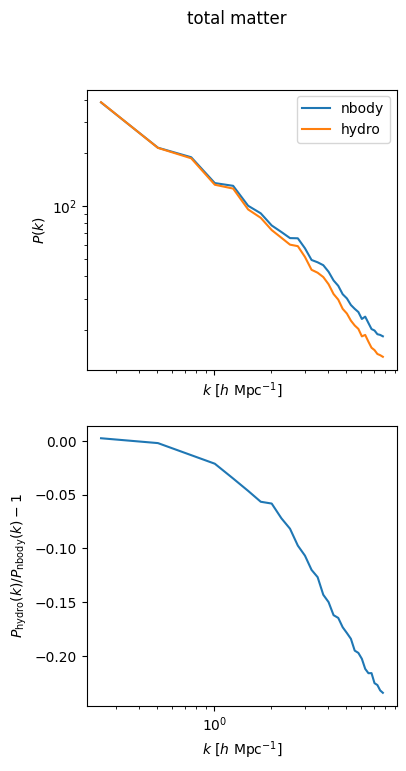

In [9]:
box_size = 25.0

def pk_wrapper(field):
    k, pk = power_spectrum(
        compensate_cic(field),
        boxsize=np.array([box_size] * 3),
        kmin=np.pi / box_size,
        dk=2 * np.pi / box_size,
    )
    return k, pk

k, n_pk_tot = pk_wrapper(n_rho_tot)
k, h_pk_tot = pk_wrapper(h_rho_tot)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(4, 2*4))

ax[0].plot(k, n_pk_tot, label="nbody")
ax[0].plot(k, h_pk_tot, label="hydro")

ax[0].set(xscale="log", yscale="log", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P(k)$")
ax[0].legend()

ax[1].plot(k, h_pk_tot/n_pk_tot - 1, label="nbody")
ax[1].set(xscale="log", yscale="linear", xlabel=r"$k$ [$h \ \mathrm{Mpc}^{-1}$]", ylabel=r"$P_\text{hydro}(k)/P_\text{nbody}(k) - 1$")

fig.suptitle("total matter")

100%|██████████| 2/2 [00:00<00:00,  2.39it/s]


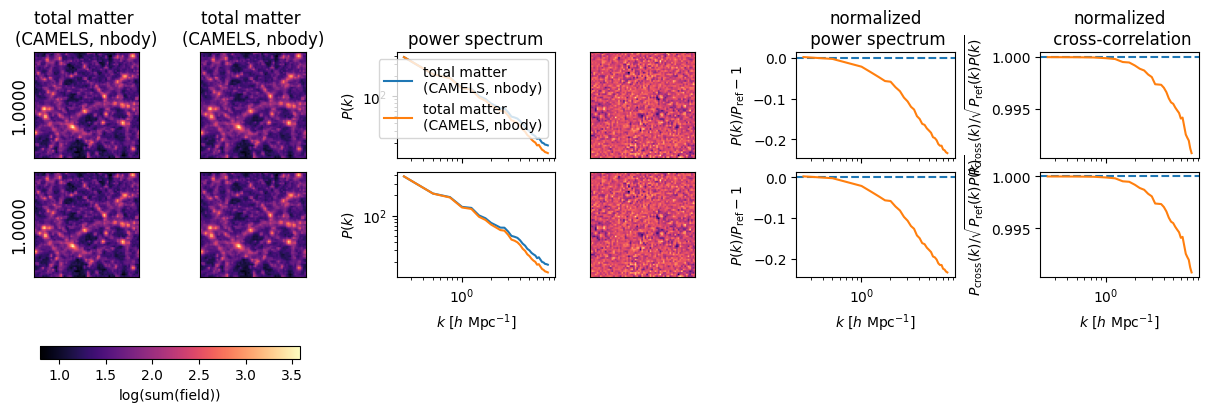

In [10]:
plotting.compare_field_evolution(
    jnp.repeat(scales, 2, axis=0),
    jnp.stack(
        [jnp.repeat(jnp.expand_dims(n_rho_tot, axis=0), 2, axis=0), jnp.repeat(jnp.expand_dims(h_rho_tot, axis=0), 2, axis=0)], 
        axis=0
    ),
    include_pk=True,
    include_reference=True,
    # values
    shared_colorbar=True,
    # cosmetics
    title=None,
    col_titles=["total matter \n(CAMELS, nbody)", "total matter \n(CAMELS, nbody)"],
)